<a href="https://colab.research.google.com/github/chanu-tha/python_Sale_efficiency_analysis/blob/main/Pen_and_Brush_sale_efficiency_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Background

Six weeks ago we launched a new line of office stationery. Despite the world becoming increasingly digital, there is still demand for notebooks, pens and sticky notes. Our focus has been on selling products to enable our customers to be more creative, focused on tools for brainstorming. We have tested three different sales strategies for this, targeted email and phone calls, as well as combining the two. We need to make sure we are using the best techniques to sell the new product effectively. The best approach may vary for each new product so we need to learn quickly what works and what doesn’t.

## Data and library imported

In [ ]:
## import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
## import data into nb
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Datacamp_practical_exam/product_sales.csv'

df = pd.read_csv(file_path)

print(df.head())


Mounted at /content/drive
   week  sales_method                           customer_id  nb_sold  revenue  \
0     2         Email  2e72d641-95ac-497b-bbf8-4861764a7097       10      NaN   
1     6  Email + Call  3998a98d-70f5-44f7-942e-789bb8ad2fe7       15   225.47   
2     5          Call  d1de9884-8059-4065-b10f-86eef57e4a44       11    52.55   
3     4         Email  78aa75a4-ffeb-4817-b1d0-2f030783c5d7       11      NaN   
4     3         Email  10e6d446-10a5-42e5-8210-1b5438f70922        9    90.49   

   years_as_customer  nb_site_visits      state  
0                  0              24    Arizona  
1                  1              28     Kansas  
2                  6              26  Wisconsin  
3                  3              25    Indiana  
4                  0              28   Illinois  


## Data Validation and Cleansing

Firstly, let's check the unique value.

In [ ]:
## check unique value on each column

for col in df.columns:
    unique_value = df[col].nunique()
    print(f"Unique values in {col}: {unique_value}")

print(df["nb_sold"].unique())

Unique values in week: 6
Unique values in sales_method: 5
Unique values in customer_id: 15000
Unique values in nb_sold: 10
Unique values in revenue: 6743
Unique values in years_as_customer: 42
Unique values in nb_site_visits: 27
Unique values in state: 50
[10 15 11  9 13  8 12  7 14 16]


The sales method should have 3 unique method which are Email, Call, Email + Call but it shows 5 unique values in the result. We need to standardize the inccorect values.

In [ ]:


df['sales_method'] = df['sales_method'].replace({'em + call': 'Email + Call', 'email': 'Email'})

print(df['sales_method'].unique())

['Email' 'Email + Call' 'Call']


Several values in the years_as_customer column are greater than the company's age. To correct inconsistencies in the years_as_customer data, any values exceeding the company's age should be replaced with the company's age.

In [ ]:
# set excessive tenure to max age

#print(df["years_as_customer"].unique())

df["years_as_customer"] = df["years_as_customer"].apply(lambda x: x if x <= 41 else 41 )

print(df["years_as_customer"].unique())

[ 0  1  6  3 10  9  7  4  2 20  8  5 17 36 15 14 19 13 12 11 30 24 22 18
 26 23 32 16 39 25 33 21 31 27 34 28 29 35 38 37 41]


Check for missing value

In [ ]:
# explore and validate the data

#df.info()

missing_value = df.groupby("sales_method")["revenue"].apply(lambda x: x.isna().sum())
print(missing_value)

sales_method
Call            181
Email           544
Email + Call    349
Name: revenue, dtype: int64


The revenue column has 1074 missing values, exceeding 5% of the total data. Since dropping these values could significantly impact further analysis, and revenue is crucial for identifying effective sales strategies, I imputed the missing values using the median revenue of nb_sold for each distinct sales method. This approach minimizes the impact on the distribution of revenue while reflecting the reality that nb_sold correlates with revenue and varies across different sales methods.

In [ ]:
df_wk = df.copy()

In [ ]:
revenue_nb_sold = df_wk.groupby(["sales_method", "nb_sold"], as_index=False)["revenue"].median()

call_median = revenue_nb_sold[revenue_nb_sold["sales_method"] == "Call"]

call_median

,sales_method,nb_sold,revenue
0,Call,7,35.060
1,Call,8,41.230
2,Call,9,43.680
3,Call,10,51.350
4,Call,11,53.475
5,Call,12,57.770
6,Call,13,65.740
7,Call,14,68.325


Impute the data by median of revenue depend on nb_sold since nb_sold and revenue have positive correlation to each other.

In [ ]:
def impute_median(df):

    for _, group in df.groupby(["sales_method", "nb_sold"]):
        group_median = group['revenue'].median()
        df.loc[group.index, "revenue"] = group["revenue"].fillna(group_median)

    return df


df_wk = impute_median(df_wk)

# check to confirm on missing value
df_wk.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            15000 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB


After validation, the dataset remains 15,000 rows and 8 columns without missing values, and I decided to keep outliers as they may affect the performance of sales approaches.


## Explore and Visualize the data

### How many customers were there for each approach?

In [ ]:
sale_count = df_wk["sales_method"].value_counts(normalize=True).reset_index()
sale_count.columns = ['sales_method', 'percentage']
sale_count = sale_count.merge(df_wk["sales_method"].value_counts().rename('count'),
                            left_on='sales_method', right_index=True, how='left')

print(sale_count)



   sales_method  percentage  count
0         Email    0.497733   7466
1          Call    0.330800   4962
2  Email + Call    0.171467   2572


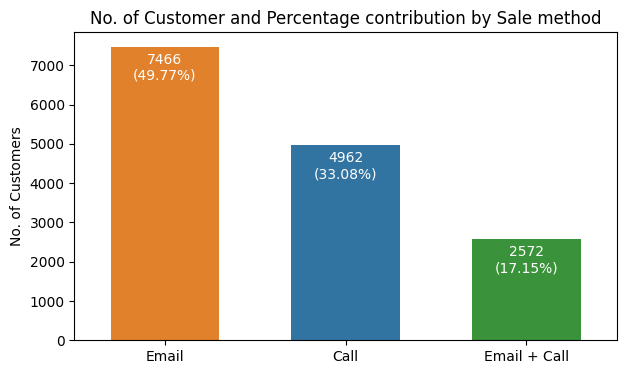

In [ ]:
## plot bar plot with both count and percentage contribution

def_color = {"Email":"#ff7f0e","Email + Call" : "#2ca02c","Call" :"#1f77b4"}

plt.figure(figsize=(7, 4))
ax = sns.barplot(x='sales_method', y='count', data=sale_count, palette= def_color, width = 0.6)


# Annotate each bar with count and percentage
for index, row in sale_count.iterrows():
    count = row['count']
    percentage = row['percentage'] * 100
    ax.annotate(f'{int(count)}\n({percentage:.2f}%)',
                (index, count),
                ha='center', va='center', fontsize=10, color='white', xytext=(0, -15),
                textcoords='offset points')

plt.title('No. of Customer and Percentage contribution by Sale method')
plt.xlabel('')
plt.ylabel('No. of Customers')
plt.show()

Over the past six weeks, Email has been the dominant sales approach, reaching 7,466 customers (49.77%).
Call follows with 4,962 customers (33.08%), while Email + Call has reached 2,572 customers (17.15%).


In [ ]:
# calculate revenue portion

revenue_by_method = df_wk.groupby("sales_method")["revenue"].sum().round(2)

revenue_percentage = round(revenue_by_method/df_wk["revenue"].sum()*100,2).reset_index()
revenue_percentage.columns = ["sales_method", "percentage"]

revenue_percentage = revenue_percentage.merge(revenue_by_method,
                            left_on='sales_method', right_index=True, how='left')
revenue_percentage = revenue_percentage.sort_values("revenue", ascending= False).reset_index()


print(revenue_percentage)

   index  sales_method  percentage    revenue
0      1         Email       50.53  725439.82
1      2  Email + Call       33.00  473838.05
2      0          Call       16.47  236395.34


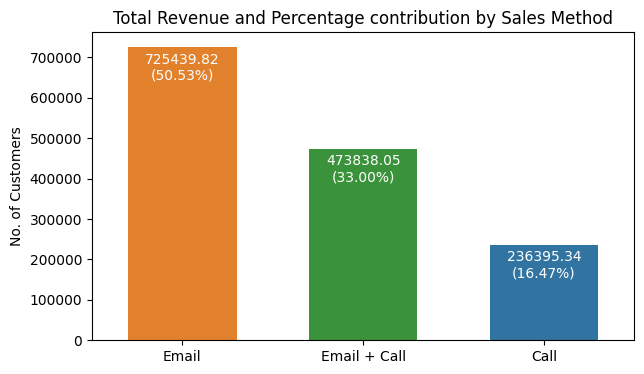

In [ ]:
# ploting revenue contribution

plt.figure(figsize=(7, 4))
ax = sns.barplot(x='sales_method', y='revenue', data= revenue_percentage, palette = def_color, width = 0.6)

# Add count values on top of each bar
for index, row in revenue_percentage.iterrows():
    count = row['revenue']
    percentage = row['percentage']
    ax.annotate(f'{count:.2f}\n({percentage:.2f}%)',
                (index, count),
                ha='center', va='center', fontsize=10, color='white', xytext=(0, -15),
                textcoords='offset points')

ax.set_xlabel("")
ax.set_ylabel("No. of Customers")
ax.set_title("Total Revenue and Percentage contribution by Sales Method")

plt.show()

In terms of revenue contribution, Email remains the top performer with \$725,439.82 (50.53%). However, Email + Call, despite reaching fewer customers, generated $473,838.05 (33.00%), indicating a higher revenue per customer compared to the Call approach, which generated \$236,395.34 (16.47%).

## Explore the revenue distribution for each method

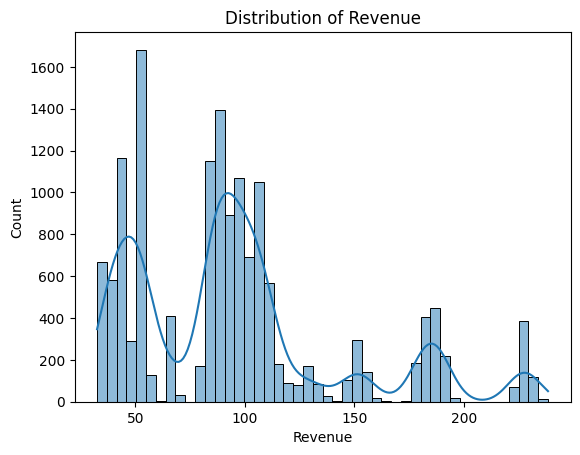

In [ ]:
# distribution of overall revenue

sns.histplot(data = df_wk, x = 'revenue', kde = True)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.show()

The overall revenue distribution is right-skewed with multiple spike nodes which can be caused by different distribution from different sale methods.

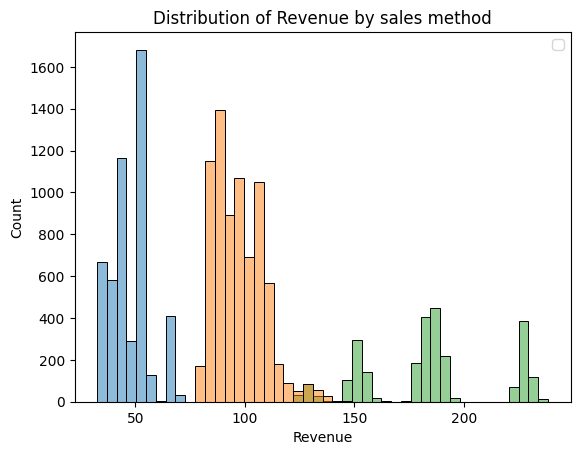

In [ ]:
# distribution of revenue by sale method

sns.histplot(data = df_wk, x = 'revenue', hue = 'sales_method', multiple = "layer", palette = def_color)
plt.title("Distribution of Revenue by sales method")
plt.xlabel("Revenue")
plt.legend()
plt.show()

After categorizing each method by colors, distinct patterns revealed. The Call method appears to generate lower-value transactions, while the Email method seems to be associated with a broader range of revenue, including a significant proportion of mid-range transactions. Notably, the Email + Call method exhibits a concentration towards higher-value transactions, suggesting a potentially more effective strategy for securing larger deals.

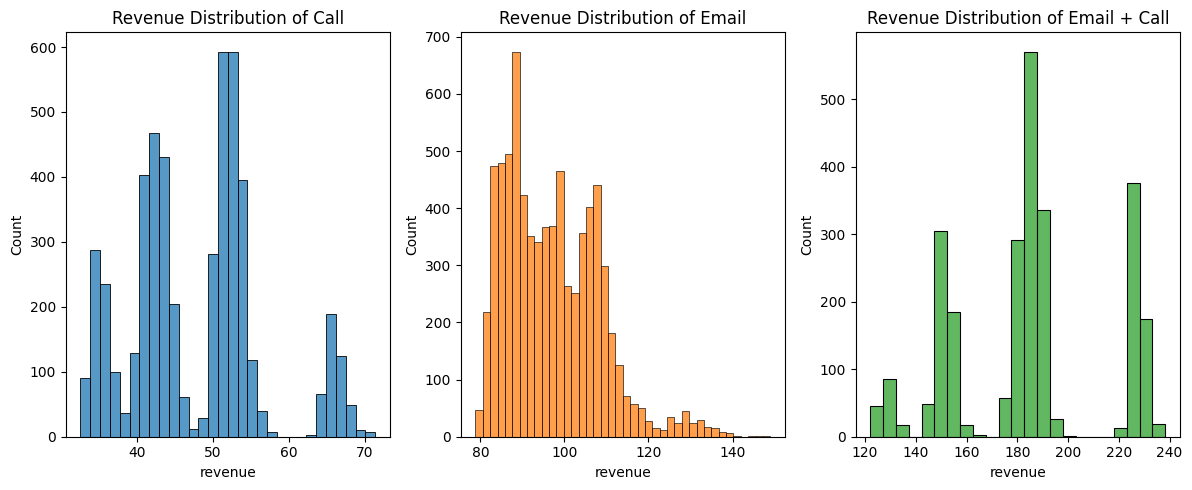

In [ ]:
# plot each sale method revenue distribution

sale_method = ["Call", "Email", "Email + Call"]
colors = ["#1f77b4","#ff7f0e","#2ca02c"]

# create subplot

fig, axes = plt.subplots(1, len(sale_method), figsize = (12,5))

for i, sale in enumerate(sale_method):
    sns.histplot(data=df_wk[df_wk["sales_method"] == sale], x = "revenue", ax=axes[i], color = colors[i])
    axes[i].set_title(f"Revenue Distribution of {sale}")

plt.tight_layout()
plt.show()

Break down into each sale method

- Call: Revenue from "Call" is concentrated in the lower range, with a right-skewed distribution (average: \$47.65, median: \$49.27). This suggests a majority of transactions fall within a narrower revenue band.
- Email: The "Email" method shows a right-skewed distribution (average: \$97.17, median: \$95.79), indicating a larger proportion of lower-value transactions. However, it captures a wider range of revenue compared to "Call."
- Email + Call: This method exhibits a near-bell-shaped distribution (average: \$184.23, median: \$184.50), suggesting a more balanced spread across revenue levels. It also has the widest revenue spread among the three methods, indicating a greater diversity in transaction values.

In [ ]:

print(df_wk.groupby("sales_method")["revenue"].agg(["mean", "median", "std"]))
print(df_wk.describe)

                    mean   median        std
sales_method                                
Call           47.641142   49.265   8.612185
Email          97.165795   95.790  11.180066
Email + Call  184.229413  184.500  29.106154
<bound method NDFrame.describe of        week  sales_method                           customer_id  nb_sold  \
0         2         Email  2e72d641-95ac-497b-bbf8-4861764a7097       10   
1         6  Email + Call  3998a98d-70f5-44f7-942e-789bb8ad2fe7       15   
2         5          Call  d1de9884-8059-4065-b10f-86eef57e4a44       11   
3         4         Email  78aa75a4-ffeb-4817-b1d0-2f030783c5d7       11   
4         3         Email  10e6d446-10a5-42e5-8210-1b5438f70922        9   
...     ...           ...                                   ...      ...   
14995     4          Call  17267b41-d048-4346-8b90-7f787690a836       10   
14996     5          Call  09e10d6f-4508-4b27-895e-4db11ce8302b       10   
14997     1          Call  839653cb-68c9-48cb-a097-0a5a3b

## The difference in overtime revenue for each sale method

Create a new DataFrame to calculate revenue, total customers, and total product sales, grouped by sales method and week of sale, for time-series plotting.

In [ ]:
# calculate revenue per customers

rev_by_cus = df_wk.groupby(["sales_method", "week"], as_index=False).agg( total_revenue = ("revenue", "sum"),
                                                                                 revenue_per_cust = ("revenue", "mean"),
                                                                          total_customers = ("customer_id", "nunique"),
                                                                          total_product_sale = ("nb_sold", "sum")).round(2)

rev_by_cus

,sales_method,week,total_revenue,revenue_per_cust,total_customers,total_product_sale
0,Call,1,26796.43,35.35,758,5366
1,Call,2,35095.39,43.60,805,7088
2,Call,3,37666.24,41.76,902,7456
3,Call,4,51716.34,51.46,1005,10259
4,Call,5,55479.73,53.14,1044,11129
5,Call,6,29641.22,66.16,448,5889
6,Email,1,246357.88,87.52,2815,24573
7,Email,2,148764.06,100.11,1486,14952
8,Email,3,106781.46,92.85,1150,10678
9,Email,4,116924.72,108.77,1075,11736


In [ ]:
rev_by_cus.groupby("sales_method")["total_revenue"].sum()

,total_revenue
sales_method,
Call,236395.35
Email,725439.83
Email + Call,473838.05


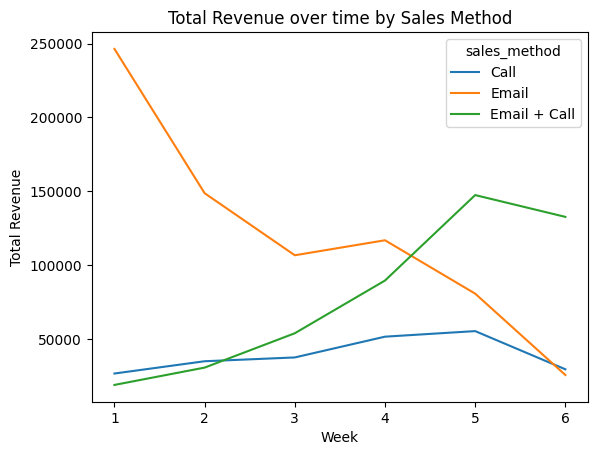

In [ ]:
# plot revenue over time


sns.lineplot(data = rev_by_cus, x="week", y="total_revenue", hue="sales_method", ci= None)
plt.xlabel("Week")
plt.ylabel("Total Revenue")
plt.title("Total Revenue over time by Sales Method")


plt.show()

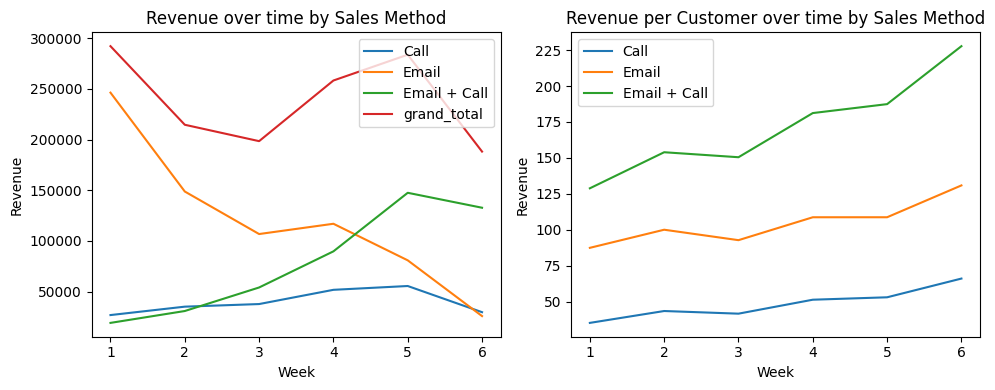

In [ ]:
# plot grapg side by side

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# plot revenue overtime
for column in rev_pivot.columns:
    if column != 'week':  # Exclude the 'week' column itself
        axes[0].plot(rev_pivot.index, rev_pivot[column], label=column)
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Revenue")
axes[0].legend(loc="upper right")
axes[0].set_title("Revenue over time by Sales Method")

# plot revenue per customer
sns.lineplot(data = rev_by_cus, x="week", y="revenue_per_cust", hue="sales_method", ci= None, ax=axes[1])
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Revenue")
axes[1].legend()
axes[1].set_title("Revenue per Customer over time by Sales Method")

plt.tight_layout()

plt.show()

There are significant differences in revenue trends over time for each sales method. The first chart shows the total revenue generated by each sales method over six weeks. We see an overall downward trend in total revenue, possibly due to factors like initial launch excitement or seasonal variations.

Looking at individual methods, Email initially dominated, generating over \$246,000 in the first week. However, its revenue declined significantly, reaching less than \$25,000 by the end of the sixth week. Call revenue showed a gradual increase, starting at around \$26,000 and peaking at over \$55,000 in week five. Email + Call demonstrated the most consistent growth, starting with around \$19,000 and surpassing both Email and Call to reach nearly \$147,000 by week five.

The second chart reveals revenue per customer. Despite the overall revenue fluctuations, all methods experienced an increase in revenue per customer. Email + Call consistently outperformed the others, starting with \$129 per customer and reaching \$228 per customer by the end of the period (\$99 increment). Email showed an increase from \$87.50 to \$131 per customer (\$43.5 increment), while Call increased from \$35 to \$66 per customer (\$31 increase).

<Figure size 1000x600 with 0 Axes>

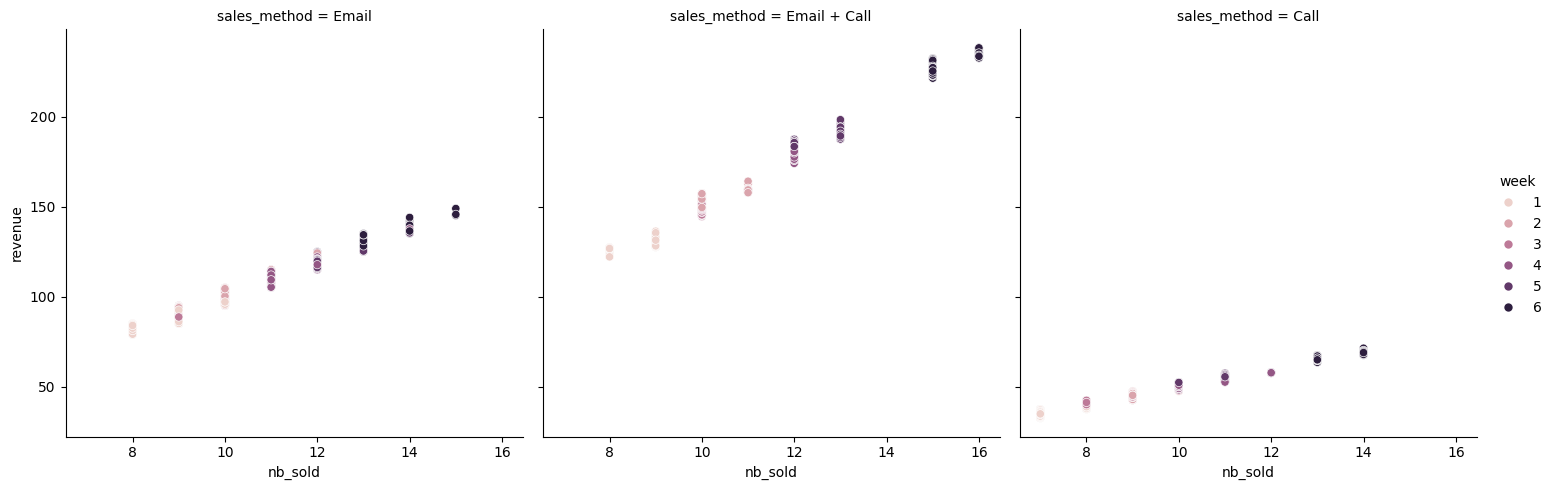

In [ ]:
##

plt.figure(figsize=(10,6))
sns.relplot(data = df_wk, x="nb_sold", y="revenue", kind="scatter",
            hue = "week", col = "sales_method")


plt.show()

A closer look at the scatter plot below reveals an intriguing dynamic. As the weeks progress after product launch, we observe a positive correlation between revenue per customer, the number of products sold, and the time elapsed. This suggests that building customer relationships and cultivating larger purchases often requires time. Factors such as customer consideration and approval processes may contribute to this observed trend.


## Hypothesis Testing

Null Hypothesis (H0): There is no significant difference in mean revenue generated across the different sales methods (email, call, and email + call).

Alternative Hypothesis (Ha): There is a significant difference in mean revenue generated across at least one of the sales methods (email, call, and email + call).  (Or, you could say:  At least one sales method has a different mean revenue than the others.)

Alpha (α): 5%

In [ ]:
# Testing a hypothesis by ANOVA

anova_data = [df_wk['revenue'][df_wk['sales_method'] == method] for method in df_wk['sales_method'].unique()]
f_statistic, p_value = stats.f_oneway(*anova_data)

print("F-statistics: ", f_statistic)
print("p-value: ", p_value)

# check significant the hypothesis
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is evidence of significant differences in revenue across sales methods.")
else:
    print("Fail to reject the null hypothesis. There is no evidence of significant differences in revenue across sales methods.")

F-statistics:  68181.66656391669
p-value:  0.0
Reject the null hypothesis. There is evidence of significant differences in revenue across sales methods.


**Statistical Significance:**

It's important to note that the observed differences in revenue per customer between the sales methods are statistically significant. This indicates that these differences are not due to chance and strongly suggests that each sales method has a different level of success.


**In conclusion**, there are significant differences in revenue trends over time for each sales method. While **Email** initially dominated in terms of total revenue, its performance declined significantly over time. In contrast, **"Email + Call"** showed consistent growth, surpassing other methods in both total revenue and revenue per customer. This suggests that **“Email + Call”** approach may be the most effective strategy for driving revenue and maximizing customer value.

Furthermore, our analysis reveals a positive correlation between revenue per customer and the time since product launch. This indicates that building strong customer relationships and cultivating larger purchases often takes time.

## Appendix

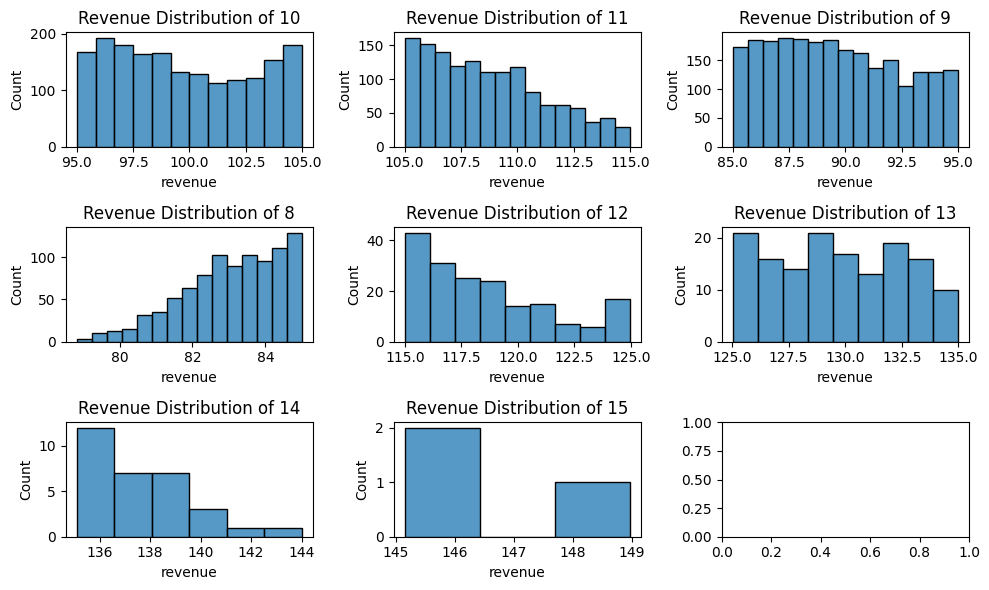

In [ ]:
# see the distribution of the revenue by sales method

call_nb_sold = df[df["sales_method"]== "Email"]["nb_sold"].unique()

# create subplot

fig, axes = plt.subplots(3, 3, figsize = (10,6))

axes = axes.flatten()

for i, sale in enumerate(call_nb_sold):
    sns.histplot(data=df[(df["sales_method"]=="Email") & (df["nb_sold"] == sale)], x = "revenue", ax=axes[i])
    axes[i].set_title(f"Revenue Distribution of {sale}")

plt.tight_layout()
plt.show()

In [ ]:
# prompt: find the skewness of df_wk[df["sales_method"] == "Email + Call"]["revenue"]

from scipy.stats import skew

skewness = skew(df_wk[df_wk["sales_method"] == "Email + Call"]["revenue"])
print(f"The skewness of revenue for 'Email + Call' sales method is: {skewness}")

skewness_c = skew(df_wk[df_wk["sales_method"] == "Call"]["revenue"])
print(f"The skewness of revenue for 'Call' sales method is: {skewness_c}")

The skewness of revenue for 'Email + Call' sales method is: 0.05518646439671973
The skewness of revenue for 'Call' sales method is: 0.45293860748489834


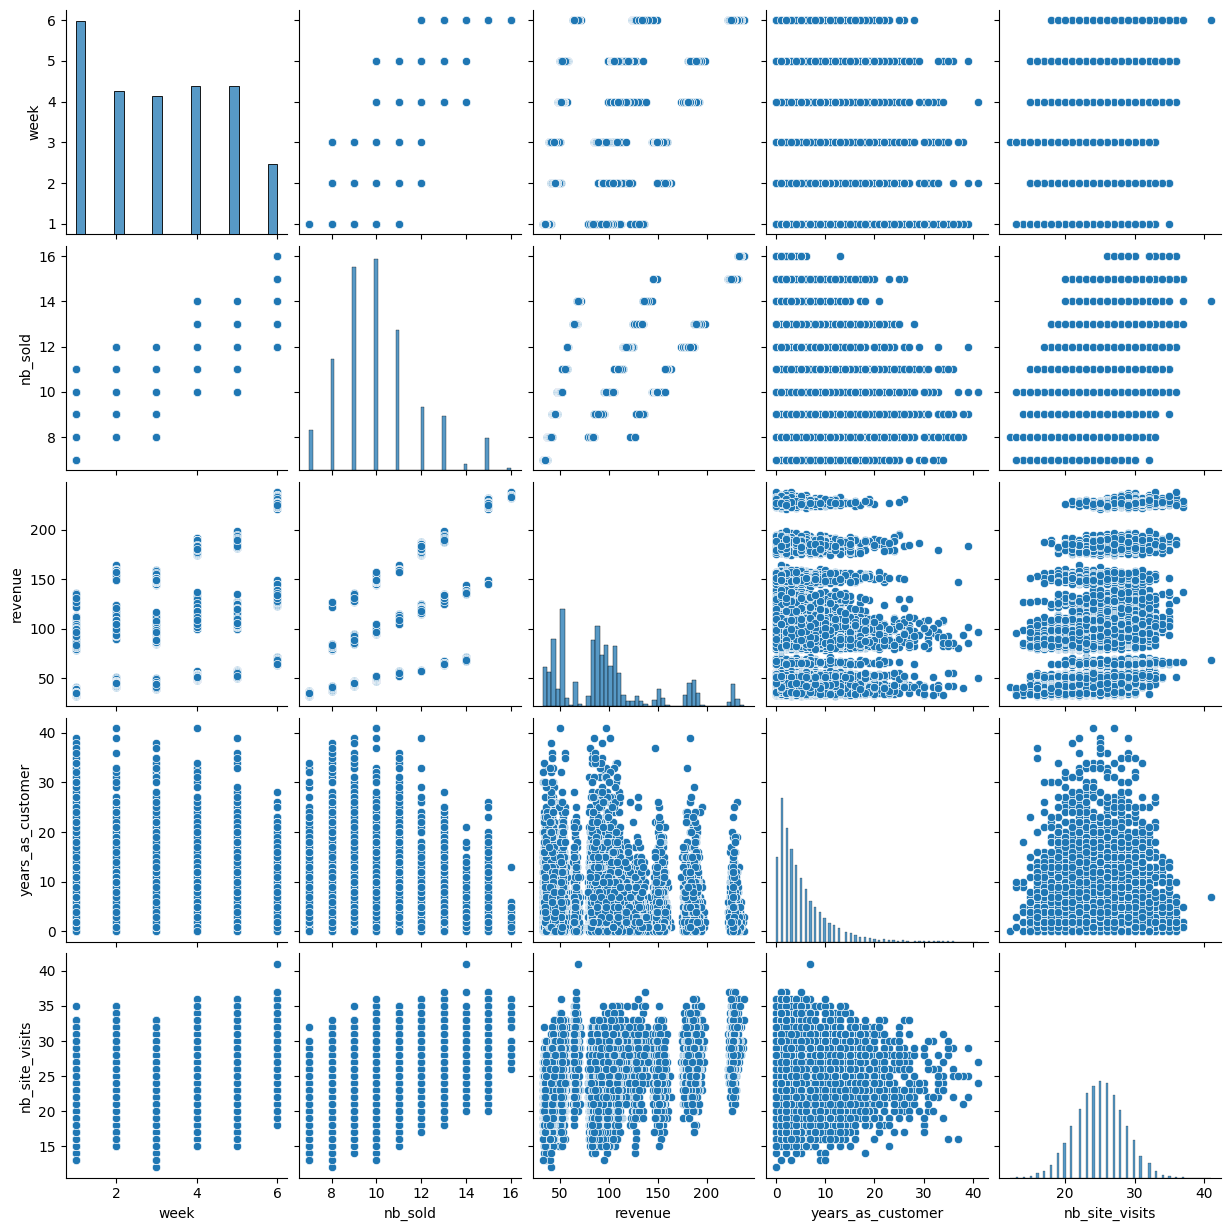

In [ ]:

sns.pairplot(data=df_wk)

plt.show()

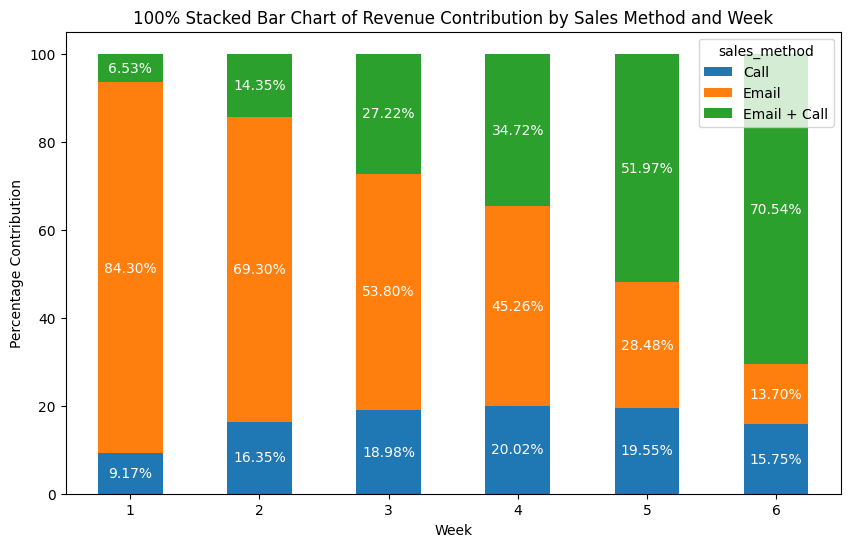

In [ ]:
## 100% stacked bar

rev_pivot = rev_by_cus.pivot_table(index = "week", columns="sales_method", values="total_revenue")
rev_pivot["grand_total"] = rev_pivot.sum(axis=1)

#print(rev_pivot)
#calculate percentage contribution

rev_pct = rev_pivot.div(rev_pivot["grand_total"], axis=0)*100

#print(rev_pct)
# drop columns 'grand_total'

rev_pct = rev_pct.drop("grand_total", axis=1)

# create 100% stacked bar chart
ax = rev_pct.plot(kind="bar", stacked=True, figsize = (10,6))

# Add percentage labels to the center of each bar
for i, col_name in enumerate(rev_pct.columns):
    for j, row_name in enumerate(rev_pct.index):
        value = rev_pct[col_name][row_name]
        ax.text(j, rev_pct.iloc[j, :i].sum() + value/2, f'{value:.2f}%', ha='center', va='center', color='white')

ax.set_ylabel('Percentage Contribution')
ax.set_xlabel('Week')
ax.set_xticklabels(rev_pct.index,rotation = 0)
ax.set_title('100% Stacked Bar Chart of Revenue Contribution by Sales Method and Week')

plt.show()


In [ ]:
# calculate cummulative revenue from week 1 to 6

# Calculate cumulative revenue
running_total = df_wk.groupby("week")["revenue"].sum().cumsum().round(2)

# Convert the cumulative sum to a DataFrame
running_total_df = running_total.reset_index()
running_total_df.rename(columns={'revenue': 'cumulative_revenue'}, inplace=True)

running_total_df

,week,cumulative_revenue
0,1,292232.07
1,2,506886.37
2,3,705365.31
3,4,963698.70
4,5,1247494.96
5,6,1435673.22


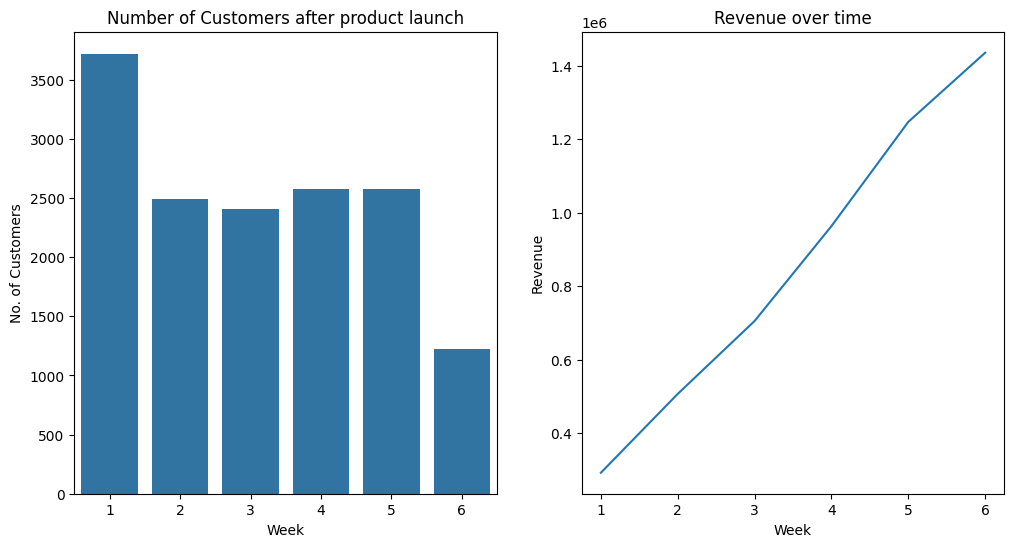

In [ ]:
# distribution of week sale after product launch

fig, axes = plt.subplots(1, 2, figsize=(12,6))


# plot distribution of week sale after product launch
sns.countplot(data = df_wk, x = "week", ax=axes[0])
axes[0].set_xlabel("Week")
axes[0].set_ylabel("No. of Customers")
axes[0].set_title("Number of Customers after product launch")

# plot running total revenue

sns.lineplot(data = running_total_df, x= "week", y="cumulative_revenue", ax=axes[1])
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Revenue")
axes[1].set_title("Revenue over time")


plt.show()

In [ ]:
# revenue growth

growth = (running_total_df['cumulative_revenue'][len(running_total_df)-1] - running_total_df['cumulative_revenue'][0])/running_total_df['cumulative_revenue'][0]
print(f"Revenue growth at the end of week 6 : {growth*100:.2f} %")

Revenue growth at the end of week 6 : 391.28 %


In [ ]:
# calculate sum of revenue for df_wk

sum_revenue = df_wk['revenue'].sum()
print(f"The sum of revenue for df_wk is: {sum_revenue}")

The sum of revenue for df_wk is: 1435673.22


   week  customer_id
0     1          148
1     2          200
2     3          359
3     4          495
4     5          787
5     6          583


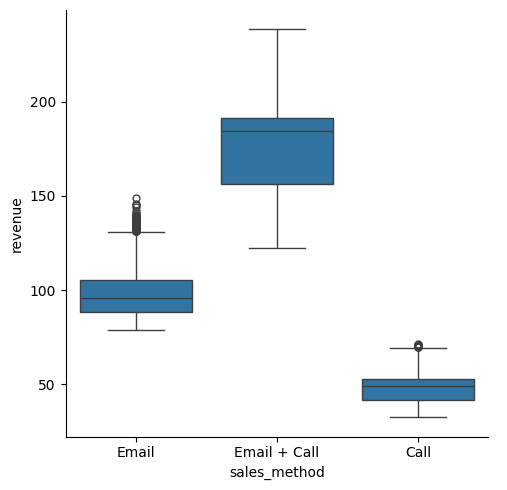

In [ ]:

#df_wk[df["sales_method"] == "Email + Call"].groupby("week")["revenue"].agg({"sum", "mean"})

##
df_email_call = df_wk[df["sales_method"]== "Email + Call"]

df_email_call_cus = df_email_call.groupby("week")["customer_id"].count().reset_index()

print(df_email_call_cus)
#sns.catplot(data = df_email_call, x = "week", y = "customer_id", kind = "box")

sns.catplot(data = df_wk, x = "sales_method", y = "revenue", kind = "box")


plt.show()

In [ ]:
# revenue on 1 week
revenue_1_wk = df_wk[df_wk["week"]==1].groupby("sales_method")["revenue"].sum()
sum_revenue_1_wk = df_wk[df_wk["week"] == 1]["revenue"].sum()

percentage_rev_wk_1 = round(revenue_1_wk/sum_revenue_1_wk *100,2)

print(percentage_rev_wk_1)

sales_method
Call             9.17
Email           84.30
Email + Call     6.53
Name: revenue, dtype: float64


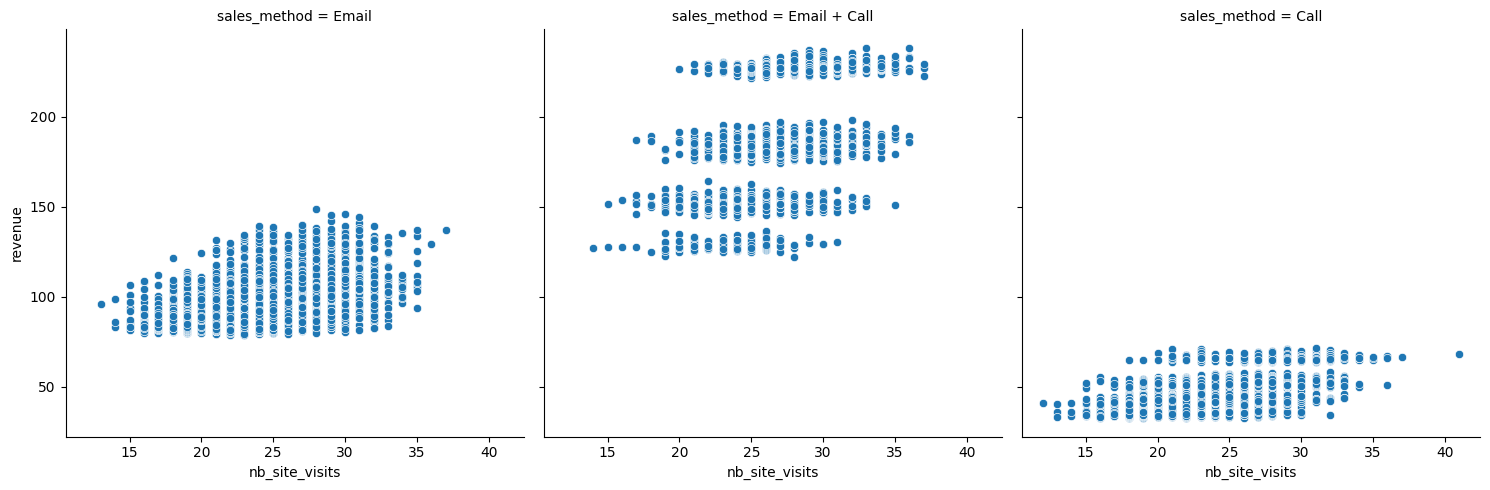

In [ ]:


sns.relplot(data = df_wk, x="nb_site_visits", y="revenue", kind="scatter", col = "sales_method")

plt.show()

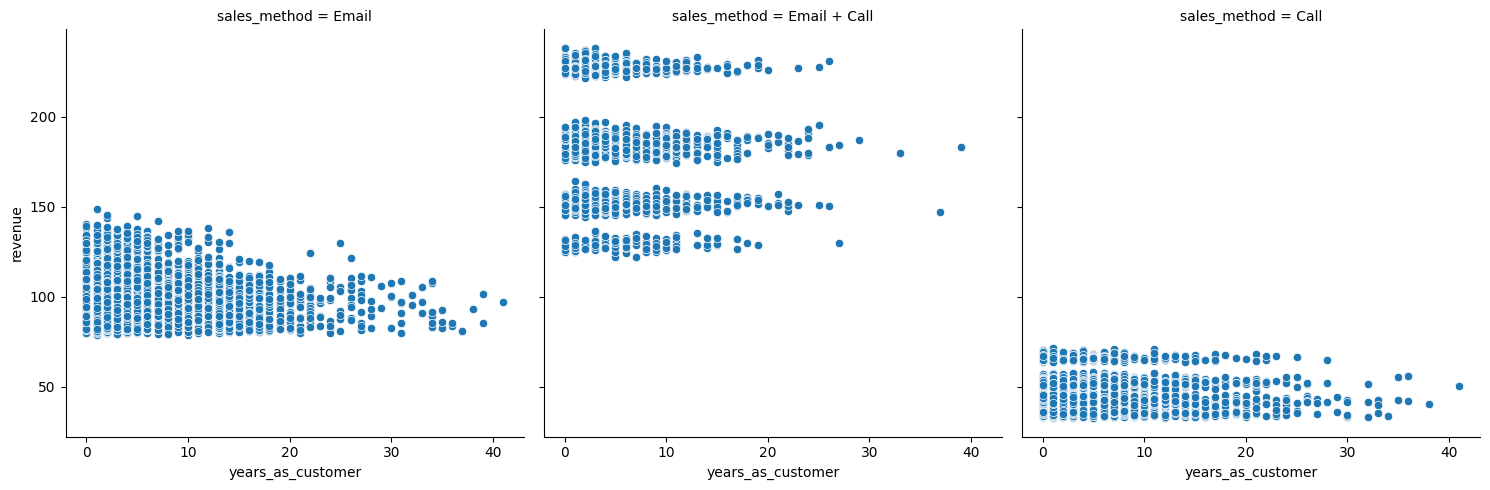

In [ ]:
sns.relplot(data = df_wk, x="years_as_customer", y="revenue",kind = "scatter", col = "sales_method" )

plt.show()

# year as customer doesn't show clear relationship with revenue